# Introduction


In this notebook we will experiment with elementary reinforcement learning algorithms on the Frozen Lake environment provided by OpenAI's Gymnasium.


## Setup


In [1]:
import sys
from pathlib import Path

for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "src" / "rl_suite").is_dir():
        sys.path.insert(0, str(_p / "src"))
        break

import gymnasium as gym

import rl_suite.RLToolbox.algorithms as rl
import rl_suite.RLToolbox.utilities as utils

%matplotlib inline



In [2]:

REWARD_SCHEMES = [(1000, -5, 0)]

In [3]:
ENV_ID = "FrozenLake-v1"
GOAL_REWARD, HOLE_REWARD, OTHER_REWARD = 1000, -5, 0
IS_SLIPPERY = True
SEED = 10

env = gym.make(
    ENV_ID,
    map_name="4x4",
    is_slippery=IS_SLIPPERY,
    render_mode="rgb_array",
    reward_schedule=(GOAL_REWARD, HOLE_REWARD, OTHER_REWARD),
)

human_runner = utils.HumanEnvironmentRunner(env)
render_fn = utils.render_env_in_notebook


## Initial Analysis


## Main Loop

Here are the functions we will be using to execute the environment in a loop:

In [4]:
# Environment execution uses rl_suite.RLToolbox.utilities.HumanEnvironmentRunner and utils.run_episode.


# Practical

## Part 3:


In [5]:
# GPI implementations live in `rl_suite.RLToolbox.algorithms` as `rl.gpi` and receive the environment when an agent is created.


In [6]:
# Stochastic policy evaluation is available as `rl.gpi.stochastic(env)`.


In [7]:

stochastic_gpi_agent = rl.gpi.stochastic(env)
stochastic_gpi_agent.get_env_info(env)
policy, values = stochastic_gpi_agent.policy_evaluation(print_num_iter=True)
print(
    "\n\nFinal policy (unchanged because this is prediction, not policy improvement):"
    f"\n{policy}\n\nFinal values:\n{values}"
)


theta=0.02 and gamma=0.9 ====> number of steps in evalution: 19


Final policy (unchanged because this is prediction, not policy improvement):
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]

Final values:
[np.float64(2.155403189518726), np.float64(1.4685104801827944), np.float64(7.474459765818058), np.float64(1.1903464903283654), np.float64(3.854455921650017), 1, np.float64(23.099520356199772), 1, np.float64(15.688541144999904), np.float64(54.744765257561134), np.float64(104.30225544334387), 1, 1, np.float64(127.87693995424438), np.float64(390.277610144705), 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

## Part 4:

Policy Improvement:


In [8]:
deterministic_gpi_agent = rl.gpi.deterministic(env)
deterministic_gpi_agent.get_env_info(env)
deterministic_gpi_agent.policy_iteration(print_num_iter=True)


theta=0.02 and gamma=0.9 ====> number of steps in evalution: 17
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 3
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
Number of iterations for policy iteration: 6


([591.021441,
  656.69049,
  729.6560999999999,
  656.69049,
  656.69049,
  1,
  810.7289999999999,
  1,
  729.6560999999999,
  810.7289999999999,
  900.81,
  1,
  1,
  900.81,
  1000.9,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0],
 [2,
  3,
  2,
  1,
  2,
  np.int64(3),
  2,
  np.int64(0),
  3,
  2,
  2,
  np.int64(3),
  np.int64(2),
  3,
  3,
  np.int64(0)])

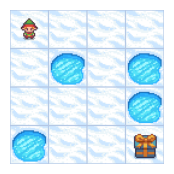

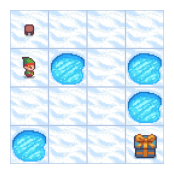

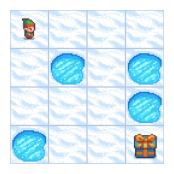

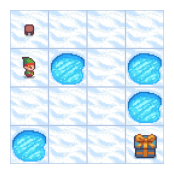

[(4, 2, 0), (0, 2, 0), (4, 2, 0), (5, 2, -5)]

In [9]:
utils.run_episode(
    env,
    agent=deterministic_gpi_agent,
    seed=SEED,
    render_fn=render_fn,
    render_each_step=True,
)


## Part 5:

Code the value iteration process

In [10]:
value_iter_agent = rl.gpi.value_iteration(env)
value_iter_agent.get_env_info(env)
value_iter_agent.value_iteration(print_num_iter=True)


theta=0.02 and gamma=0.9 ====> number of steps in evalution: 7


Clearly value iteration takes far fewer iterations than policy iteration. Now we will test value iteration:

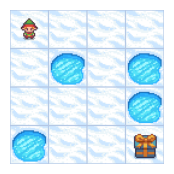

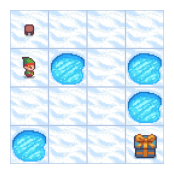

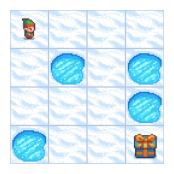

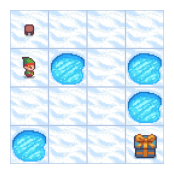

[(4, 2, 0), (0, 2, 0), (4, 2, 0), (5, 2, -5)]

In [11]:
utils.run_episode(
    env,
    agent=value_iter_agent,
    seed=SEED,
    render_fn=render_fn,
    render_each_step=True,
)


<!-- # Appendix A

Here is the full print of "env.unwrapped.P": -->